TASK - 1 (INSPECTION OF DATA)
-SUMMARY OF CONTENTS
-SIZE

In [2]:
import pandas as pd
import numpy as np

aqi = pd.read_csv("city_day (1).csv")
crop= pd.read_csv("crop_production (1).csv")

if not aqi.empty:
	print("AQI Dataset:")
	print(" ++++++++++++++++++ aqi dataset  ++++++++++++++++++")
	print("Shape:", aqi.shape)
	print("\nColumns:")
	print(aqi.columns.tolist())
	print("\nData Types:")
	print(aqi.dtypes)
	print("\nMissing Values:")
	print(aqi.isnull().sum())
	print("\nDuplicate Records:")
	print(aqi.duplicated().sum())
	print("\nStatistical Summary:")
	display(aqi.describe())
else:
	print("AQI Dataset not loaded or empty.")

print("\n\n========== CROP DATASET ==========")
if not crop.empty:
	print("Shape:", crop.shape)
	print("\nColumns:")
	print(crop.columns.tolist())
	print("\nData Types:")
	print(crop.dtypes)
	print("\nMissing Values:")
	print(crop.isnull().sum())
	print("\nDuplicate Records:")
	print(crop.duplicated().sum())
	print("\nStatistical Summary:")
	display(crop.describe())
else:
	print("Crop Dataset not loaded or empty.")

AQI Dataset:
 ++++++++++++++++++ aqi dataset  ++++++++++++++++++
Shape: (29531, 16)

Columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Data Types:
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

Missing Values:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Duplicate Records:
0

Statistical Summary:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000




========== CROP DATASET ==========
Shape: (246091, 7)

Columns:
['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']

Data Types:
State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
dtype: object

Missing Values:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

Duplicate Records:
0

Statistical Summary:


,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


### Observations

1. AQI dataset contains a large number of missing values in columns such as
   PM10, NH3, Xylene, Toluene and AQI.x
2. Crop dataset contains missing values in the Production column.
3. No duplicate records were detected in either dataset.
4. Some pollutant columns may contain extreme values that need further investigation.
5. Missing AQI values could significantly affect any future machine learning model.

TASK - 2

In [3]:
print("Before Treatment")
print("\nAQI Dataset")
print(aqi.isnull().sum())

print("\nCrop Dataset")
print(crop.isnull().sum())

# AQI Dataset

for col in aqi.select_dtypes(include=np.number).columns:
    aqi[col] = aqi[col].fillna(aqi[col].median())

aqi["AQI_Bucket"] = aqi["AQI_Bucket"].fillna(
    aqi["AQI_Bucket"].mode()[0]
)

# Crop Dataset

crop["Production"] = crop["Production"].fillna(
    crop["Production"].median()
)

Before Treatment

AQI Dataset
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Crop Dataset
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


In [4]:
print("Before Duplicate Removal")

print("AQI:", len(aqi))
print("Crop:", len(crop))

aqi = aqi.drop_duplicates()
crop = crop.drop_duplicates()

print("\nAfter Duplicate Removal")

print("AQI:", len(aqi))
print("Crop:", len(crop))

Before Duplicate Removal
AQI: 29531
Crop: 246091

After Duplicate Removal
AQI: 29531
Crop: 246091


### Inconsistencies Fixed

1. Removed leading/trailing spaces.
2. Standardised capitalisation.
3. Corrected historical state names.
4. Removed duplicate records.

These steps ensure reliable future merging operations.

TASK - 3

In [6]:

print("\nUnique States in AQI Dataset:")
aqi_states = sorted(aqi["City"].unique())   # AQI dataset does not have State column

print("\nUnique States in Crop Dataset:")
crop_states_before = sorted(crop["State_Name"].unique())

print(crop_states_before)


Unique States in AQI Dataset:

Unique States in Crop Dataset:
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir ', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana ', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [7]:
crop["State_Name"] = crop["State_Name"].str.strip()

# Standardise capitalisation
crop["State_Name"] = crop["State_Name"].str.title()

# Historical/alternative state names mapping
state_mapping = {
    "Orissa": "Odisha",
    "Uttaranchal": "Uttarakhand",
    "Andaman & Nicobar Islands": "Andaman And Nicobar Islands",
    "Dadra & Nagar Haveli": "Dadra And Nagar Haveli",
    "Nct Of Delhi": "Delhi"
}

crop["State_Name"] = crop["State_Name"].replace(state_mapping)



In [8]:
crop_states_after = sorted(crop["State_Name"].unique())

print("\n========== INCONSISTENCIES FOUND ==========")

for old, new in state_mapping.items():
    if old in crop_states_before:
        print(f"{old}  -->  {new}")

print("\nLeading/trailing spaces removed.")
print("Capitalisation standardised.")



========== INCONSISTENCIES FOUND ==========

Leading/trailing spaces removed.
Capitalisation standardised.


In [9]:
aqi_before = len(aqi)
crop_before = len(crop)

aqi_duplicates = aqi.duplicated().sum()
crop_duplicates = crop.duplicated().sum()

print("\nDuplicate Records Found:")
print("AQI:", aqi_duplicates)
print("Crop:", crop_duplicates)

aqi = aqi.drop_duplicates()
crop = crop.drop_duplicates()

print("\n========== AFTER DUPLICATE REMOVAL ==========")

print("AQI Records:", len(aqi))
print("Crop Records:", len(crop))



Duplicate Records Found:
AQI: 0
Crop: 0

========== AFTER DUPLICATE REMOVAL ==========
AQI Records: 29531
Crop Records: 246091


In [10]:

print("\n========== FINAL STATE LIST ==========")

print("\nCrop Dataset States:")
print(sorted(crop["State_Name"].unique()))

print("\nTotal Unique Crop States:",
      crop["State_Name"].nunique())

print("\nTask 3 Completed Successfully.")
print("State names have been standardised and duplicate records removed.")
print("Datasets are now ready for reliable merging.")


========== FINAL STATE LIST ==========

Crop Dataset States:
['Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra And Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

Total Unique Crop States: 33

Task 3 Completed Successfully.
State names have been standardised and duplicate records removed.
Datasets are now ready for reliable merging.


TASK - 4

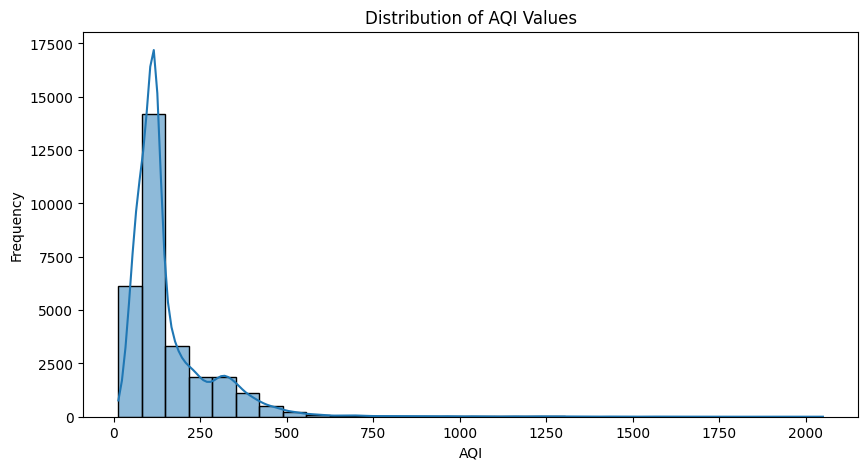

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(aqi["AQI"], bins=30, kde=True)

plt.title("Distribution of AQI Values")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()


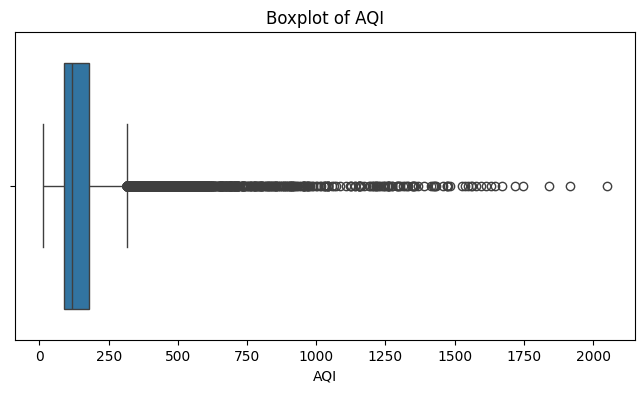

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=aqi["AQI"])

plt.title("Boxplot of AQI")
plt.xlabel("AQI")
plt.show()

### Findings

1. Most AQI values are concentrated within a moderate range.
2. Several extremely high AQI readings exist, causing the mean AQI to be larger than the typical city AQI.

Therefore, the average AQI alone may not accurately represent most cities.

TASK - 5

In [ ]:
Q1 = aqi["AQI"].quantile(0.25)
Q3 = aqi["AQI"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = aqi[
    (aqi["AQI"] < lower) |
    (aqi["AQI"] > upper)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 3192


In [ ]:
aqi_before = aqi["AQI"].copy()

aqi["AQI"] = np.where(
    aqi["AQI"] > upper,
    upper,
    np.where(aqi["AQI"] < lower, lower, aqi["AQI"])
)

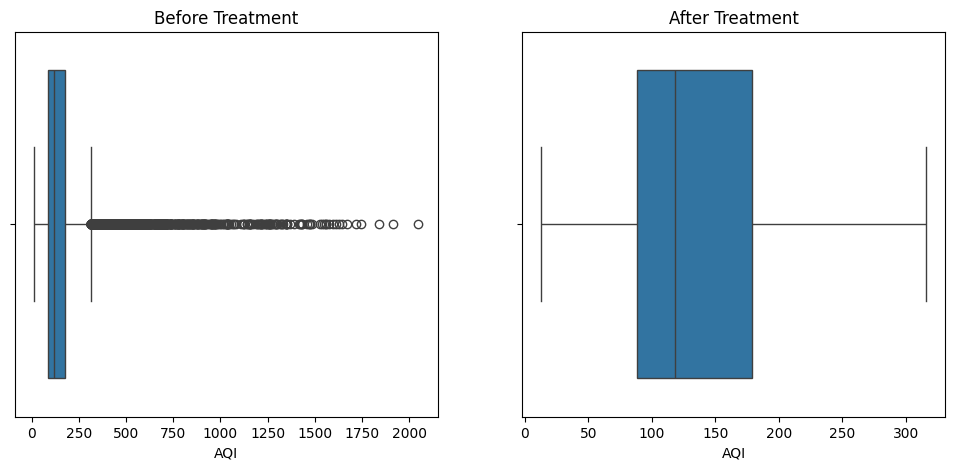

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(x=aqi_before, ax=ax[0])
ax[0].set_title("Before Treatment")

sns.boxplot(x=aqi["AQI"], ax=ax[1])
ax[1].set_title("After Treatment")

plt.show()

### Outlier Treatment Summary

Method Used:
- IQR Method for Detection
- Winsorization (Capping) for Treatment

Reason:
- Removes distortion caused by unrealistic AQI values.
- Retains valuable observations.
- Produces more reliable statistics and future machine learning models.

Result:
- Extreme AQI readings were reduced without deleting records.